## _Topic Modeling based on Reviews_
***
<b>DESCRIPTION</b>

You are asked to analyze customer reviews from an e-commerce platform. More specifically, you will perform topic modeling to identify common themes in the reviews, apply POS tagging to extract grammatical information and utilize lemmatization to normalize the words for better
analysis.

<b>Problem Statement: </b>

A popular mobile phone brand, Lenovo has launched their budget smartphone in the Indian market. The client wants to understand the VOC (voice of the customer) on the product. This will be useful to not just evaluate the current product, but to also get some direction for developing the product pipeline. The client is particularly interested in the different aspects that customers care about. Product reviews by customers on a leading e-commerce site should provide a good view.

<b>Domain: Amazon reviews for a leading phone brand</b>

- Analysis to be done: POS tagging, topic modeling using LDA, and topic interpretation

<b> Content: </b>

- Dataset: ‘K8 Reviews v0.2.csv’

<b>Columns:</b>
- Sentiment: The sentiment against the review (4,5 star reviews are positive, 1,2 are negative)
- Reviews: The main text of the review

<b>Steps to perform:</b>

Discover the topics in the reviews and present it to business in a consumable format. Employ techniques in syntactic processing and topic modeling.
Perform specific cleanup, POS tagging, and restricting to relevant POS tags, then, perform topic modeling using LDA.

<b>Tasks: </b>
- Read the .csv file using Pandas. Take a look at the top few records.
- Normalize casings for the review text and extract the text into a list for easier manipulation.
- Tokenize the reviews using NLTKs word_tokenize function.
- Perform parts-of-speech tagging on each sentence using the NLTK POS tagger.
- For the topic model, we should  want to include only nouns.
- Find out all the POS tags that correspond to nouns.
- Limit the data to only terms with these tags.
- Lemmatize.
- Different forms of the terms need to be treated as one.
- No need to provide POS tag to lemmatizer for now.
- Remove stopwords and punctuation (if there are any).
- Create a topic model using LDA on the cleaned up data with 12 topics.
- Print out the top terms for each topic.
- What is the coherence of the model with the c_v metric?
- Analyze the topics through the business lens.
- Determine which of the topics can be combined.
- Create topic model using LDA with what you think is the optimal number of topics
- What is the coherence of the model?
- Create a table with the topic name and the top 10 terms in each to present to the  business.



In [1]:
# write the list of necessary packages here:
!pip install pandas
!pip install nltk
!pip install spacy
!pip install scikit-learn
!pip install gensim
!pip install matplotlib
!pip install seaborn

## _Import Libraries and Load the Data_

In [2]:
# import your packages here:
import numpy as np
import pandas as pd
#file and system operations
import os
import sys
#visualization imports
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
#consistent sized plots
from pylab import rcParams
rcParams['figure.figsize']=12,5
rcParams['axes.labelsize']=12
rcParams['ytick.labelsize']=12
rcParams['xtick.labelsize']=12
#handle unwanted warnings
import warnings
warnings.filterwarnings(action='ignore',category=DeprecationWarning)
warnings.filterwarnings(action='ignore',category=FutureWarning)
#view all the columns
pd.options.display.max_columns = None
#basic text manipulation libraries
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

### _Load the Reviews Data_

In [4]:
reviews = pd.read_csv('K8 Reviews v0.2.csv',delimiter=',')
reviews.head(3)

,sentiment,review
0,1,Good but need updates and improvements
1,0,"Worst mobile i have bought ever, Battery is dr..."
2,1,when I will get my 10% cash back.... its alrea...


In [5]:
#check the number of reviews
len(reviews)

14675

In [6]:
#check the basic info
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14675 entries, 0 to 14674
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  14675 non-null  int64 
 1   review     14675 non-null  object
dtypes: int64(1), object(1)
memory usage: 229.4+ KB


- _There are no null values or missing values in the dataset_

In [7]:
#check the sentiment labels
reviews['sentiment'].value_counts()

,count
sentiment,
0,7712
1,6963


In [8]:
sns.countplot(reviews['sentiment'])
plt.title('Count of the review sentiments')
plt.show()

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7f088ed4e4d0> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7f088ed4d1b0> (for post_execute):


KeyboardInterrupt: 

- _The data seems to be fairly balanced. However, the objective of this project is to do topic modeling and not sentiment classification_

## _Text Preprocessing_
_Following steps will be performed_
- Tokenization - Split the text into sentences and sentences into words. Lowercase the words and remove any punctuation_
- All stopwords will be removed_
- Eliminate the tokens except nouns, noun phrases and verbs.
- Words are lemmatized - words in third person are changed to first person and words in future and past tense are changed to present tense_

In [35]:
# write your code here:
import nltk
import string
from nltk import pos_tag, WordNetLemmatizer
from nltk.corpus import wordnet
import re

nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
punctuation_pattern = re.compile(r'[^\w\s]')


lemmatizer = WordNetLemmatizer()
sentences = sent_tokenize(reviews['review'][1])

def getpos(tag):
    if tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return None

def tokenize_text(text):
    if isinstance(text, str):
        sentences = sent_tokenize(text)
        words = [
            word.lower()
            for sentence in sentences
            for word in word_tokenize(sentence)
            if not punctuation_pattern.match(word) and word.lower() not in stop_words
        ]
        pos_tags = pos_tag(words)
        filtered_tokens = [
            word for word, tag in pos_tags
            if tag.startswith('N') or tag.startswith('V')
        ]
        lemma_words = []
        for word, tag in pos_tags:
            wordnet_pos = getpos(tag)
            if wordnet_pos:
                lemma_words.append(lemmatizer.lemmatize(word, pos=wordnet_pos))
            else:
                lemma_words.append(word)

        return lemma_words
    else:
        return []

tokenized_text = []
for i in range(0,len(reviews)):
  tokenized_text.append(tokenize_text(reviews['review'][i]))



[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


### Topic Modeling

Implement topic modeling using Latent Dirichlet Allocation (LDA) which is a topic modeling technique for uncovering the central topics and their distributions across a set of documents. Identify and list the top 5 topics found in the reviews along with their associated keywords.

In [52]:
# write your code here:
from gensim import corpora
from gensim.models import LdaModel
from collections import defaultdict

dictionary = corpora.Dictionary(tokenized_text)
dictionary.filter_extremes(no_below=10, no_above=0.8)
corpus = [dictionary.doc2bow(doc) for doc in tokenized_text]

lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=8, random_state=42, passes=10, alpha='auto',iterations=210)

print("Top 5 Topics and Associated Keywords:")
topics = lda_model.print_topics(num_topics=5, num_words=10)
for i, topic in topics:
    print(f"Topic {i + 1}: {topic}")


Top 5 Topics and Associated Keywords:
Topic 3: 0.078*"charge" + 0.072*"battery" + 0.035*"day" + 0.031*"take" + 0.030*"drain" + 0.029*"use" + 0.028*"charger" + 0.028*"hour" + 0.025*"fast" + 0.022*"month"
Topic 5: 0.085*"phone" + 0.037*"n't" + 0.031*"network" + 0.026*"work" + 0.026*"buy" + 0.023*"issue" + 0.022*"problem" + 0.021*"use" + 0.020*"sim" + 0.014*"get"
Topic 2: 0.113*"camera" + 0.053*"good" + 0.042*"quality" + 0.026*"sound" + 0.025*"dual" + 0.019*"work" + 0.019*"front" + 0.016*"well" + 0.016*"mode" + 0.014*"depth"
Topic 8: 0.025*"screen" + 0.021*"n't" + 0.021*"call" + 0.016*"phone" + 0.016*"like" + 0.014*"work" + 0.012*"option" + 0.012*"lenovo" + 0.011*"use" + 0.011*"feature"
Topic 1: 0.164*"good" + 0.130*"phone" + 0.052*"nice" + 0.042*"mobile" + 0.036*"product" + 0.035*"price" + 0.034*"best" + 0.028*"awesome" + 0.024*"great" + 0.020*"camera"


In [53]:
from gensim.models import CoherenceModel

coherence_model_lda = CoherenceModel(model=lda_model, texts=tokenized_text, dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()

print(f'C_v Coherence Score: {coherence_lda}')


C_v Coherence Score: 0.65379091553377


### Reporting

Summarizing the findings, including:
• How did you select the number of topics?
• Coherence score measures how semantically related the top words are in each topic.
Which coherence type did you employ (c v, u mass or uci)?
• The most common topics identified in the reviews.
• Print examples of reviews that belong to each topic.



*   The number of topics was chosen based on experimentation. I tried values between 5-15. I look for better Coherence Score.
*   I choose c_v. A coherence score measures how well the words in a topic fit together. It checks whether the top words in a topic are related to each other in a meaningful way.
*   The most common topics identified in the reviwes:







In [54]:
print("Top 5 Topics and Associated Keywords:")
topics = lda_model.print_topics(num_topics=5, num_words=10)
for i, topic in topics:
    print(f"Topic {i + 1}: {topic}")

Top 5 Topics and Associated Keywords:
Topic 3: 0.078*"charge" + 0.072*"battery" + 0.035*"day" + 0.031*"take" + 0.030*"drain" + 0.029*"use" + 0.028*"charger" + 0.028*"hour" + 0.025*"fast" + 0.022*"month"
Topic 5: 0.085*"phone" + 0.037*"n't" + 0.031*"network" + 0.026*"work" + 0.026*"buy" + 0.023*"issue" + 0.022*"problem" + 0.021*"use" + 0.020*"sim" + 0.014*"get"
Topic 2: 0.113*"camera" + 0.053*"good" + 0.042*"quality" + 0.026*"sound" + 0.025*"dual" + 0.019*"work" + 0.019*"front" + 0.016*"well" + 0.016*"mode" + 0.014*"depth"
Topic 8: 0.025*"screen" + 0.021*"n't" + 0.021*"call" + 0.016*"phone" + 0.016*"like" + 0.014*"work" + 0.012*"option" + 0.012*"lenovo" + 0.011*"use" + 0.011*"feature"
Topic 1: 0.164*"good" + 0.130*"phone" + 0.052*"nice" + 0.042*"mobile" + 0.036*"product" + 0.035*"price" + 0.034*"best" + 0.028*"awesome" + 0.024*"great" + 0.020*"camera"


In [56]:
review_topics = [lda_model.get_document_topics(bow) for bow in corpus]

dominant_topics = [max(topics, key=lambda x: x[1])[0] for topics in review_topics]
topic_reviews = defaultdict(list)
for i, topic in enumerate(dominant_topics):
    topic_reviews[topic].append(reviews['review'][i])

print("\nExamples of Reviews for Each Topic:")
for topic_id, reviews_list in topic_reviews.items():
    print(f"\nTopic {topic_id + 1}:")
    for review in reviews_list[:3]:
        print(f"- {review}")


Examples of Reviews for Each Topic:

Topic 2:
- Good but need updates and improvements
- The battery level has worn down
- Galery problem and there is not atmos speakerNormal speaker in this phone

Topic 3:
- Worst mobile i have bought ever, Battery is draining like hell, backup is only 6 to 7 hours with internet uses, even if I put mobile idle its getting discharged.This is biggest lie from Amazon & Lenove which is not at all expected, they are making full by saying that battery is 4000MAH & booster charger is fake, it takes at least 4 to 5 hours to be fully charged.Don't know how Lenovo will survive by making full of us.Please don;t go for this else you will regret like me.
- when I will get my 10% cash back.... its already 15 January..
- Good phone but charger not working / damage within 2 months.

Topic 1:
- Good
- Very good phone slim good battry backup good screen love it
- Best product according to their prize range and it's specification comparison to another mobile(under rang

### Visualization

Plot word clouds for each topic displaying associated keywords

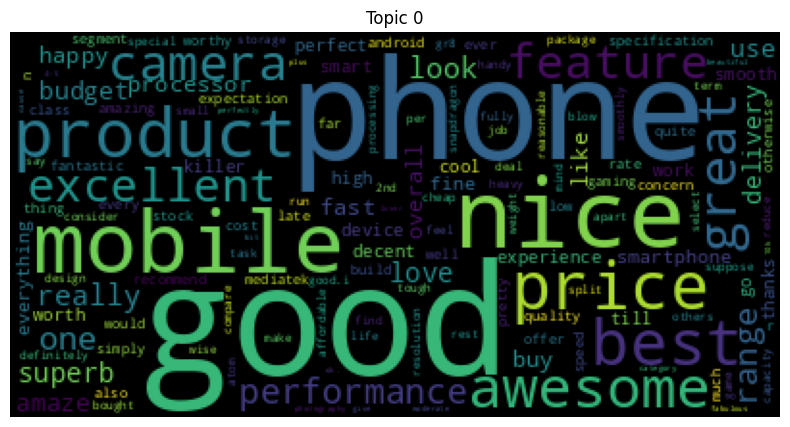

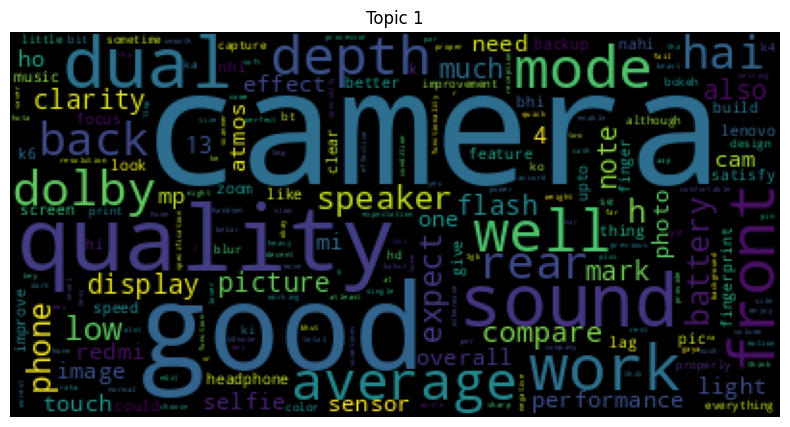

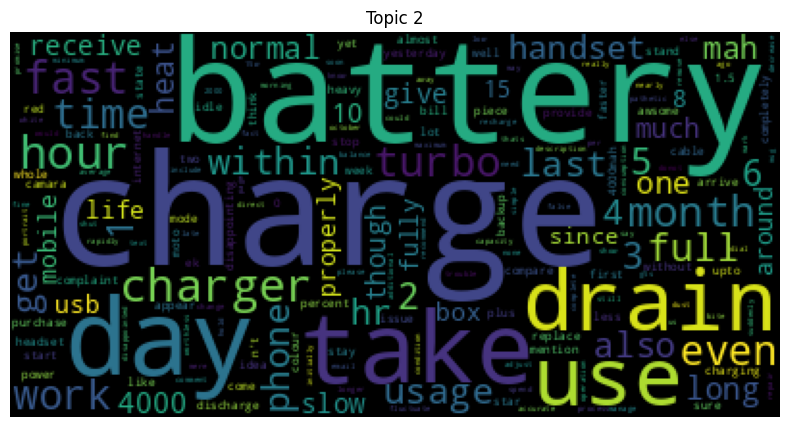

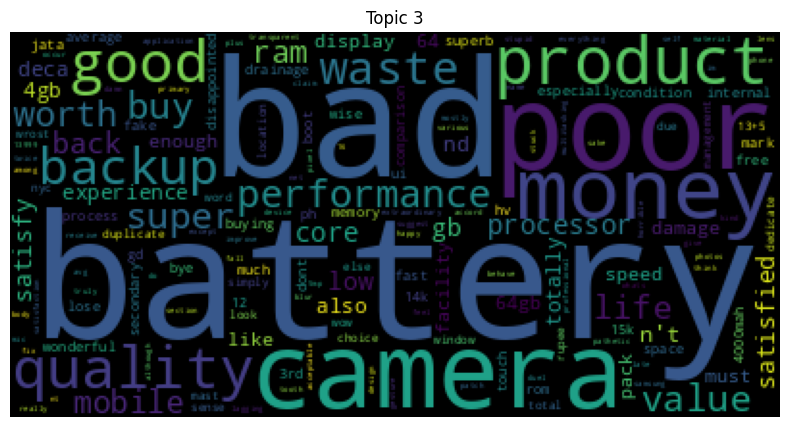

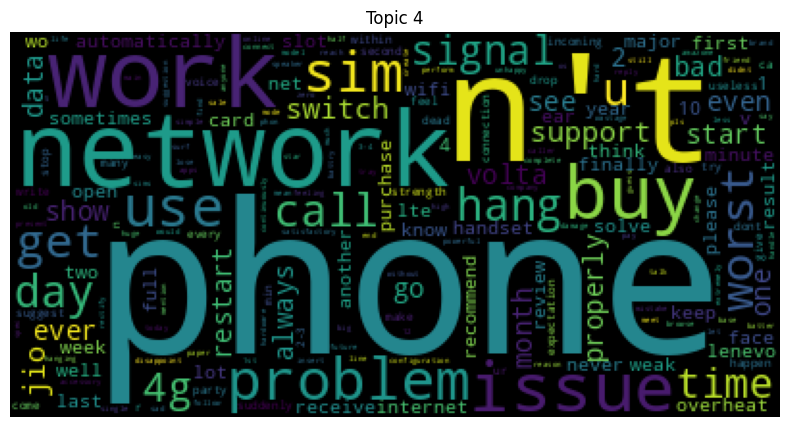

In [57]:
# write your code here:
from gensim.test.utils import common_texts
from gensim.corpora.dictionary import Dictionary
import matplotlib.pyplot as plt
from wordcloud import WordCloud

for t in range(5):
    plt.figure()
    plt.imshow(WordCloud().fit_words(dict(lda_model.show_topic(t, 200))))
    plt.axis("off")
    plt.title("Topic " + str(t))
    plt.show()
